# 🔗 Mapeo entre Datasets — DxSindromatico → Síntomas

Este notebook analiza el mapeo NLP entre los diagnósticos sindrómicos del hospital y las columnas de síntomas del dataset de enfermedades.  
El mapeo usa **TF-IDF coseno + RapidFuzz + reglas semánticas** para encontrar similitudes entre textos de dominios diferentes.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.config import SINDROMATICO_A_SINTOMAS, MORBILIDAD_XLSX

## 1. Cargar datos y el mapeo NLP generado

In [2]:
# Dataset hospital
df_h = pd.read_excel(MORBILIDAD_XLSX, usecols=['DxSindromatico', 'Triage'])
df_h = df_h.dropna(subset=['DxSindromatico'])
dx_unicos = sorted(df_h['DxSindromatico'].unique())

# Cargar CSV de mapeo generado por mapeo_nlp.py
mapeo_path = os.path.join(os.getcwd(), '..', 'outputs', 'mapeo_dx_sintomas.csv')
df_mapeo = pd.read_csv(mapeo_path)

print(f'DxSindromatico únicos en hospital:  {len(dx_unicos)}')
print(f'Entradas en SINDROMATICO_A_SINTOMAS: {len(SINDROMATICO_A_SINTOMAS)}')
print(f'Con síntomas mapeados: {(df_mapeo.n_sintomas > 0).sum()}')
df_mapeo.head(10)

DxSindromatico únicos en hospital:  297
Entradas en SINDROMATICO_A_SINTOMAS: 277
Con síntomas mapeados: 277


,dx_sindromatico,n_sintomas,sintomas
0,ABDOMEN AGUDO,7,abdomen hinchado | dolor abdominal agudo | dol...
1,ABORTO RETENIDO,3,sangrado intermenstrual | dolor abdominal agud...
2,ABSCESO CUTANEO FURUNCULO DE SITIO NO ESPECIFI...,0,NaN
3,ABSCESO DE LA GLANDULA DE BARTHOLINO,0,NaN
4,ABSCESO EN MAMA ASOCIADO CON EL PARTO,0,NaN
5,ABSCESO PERIMIGDALINOS,4,enrojecimiento del pene | pus en el esputo | f...
6,ABSCESO PIEL,10,dolor de piel | lunares en la piel | hinchazón...
7,ABUSO FISICO,7,abuso de alcohol | abuso de drogas | visión di...
8,ABUSO SEXUAL,6,abuso de alcohol | abuso de drogas | pérdida d...
9,ACCIDENTE CEREBRO VASCULAR,3,debilidad | dificultad para hablar | dolor de ...


## 2. Cobertura del mapeo

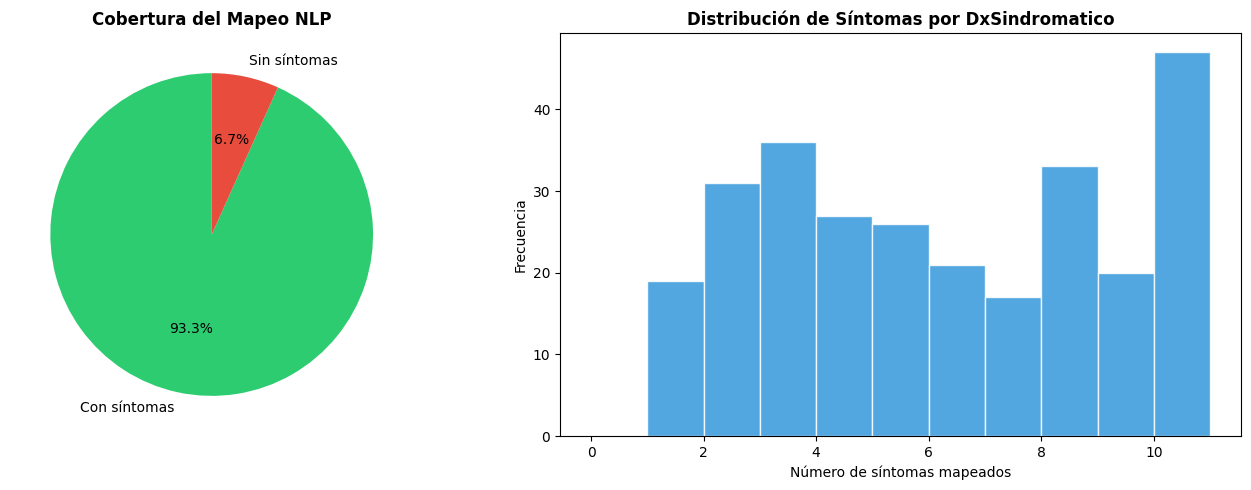


Cobertura: 277/297 = 93.3%
Sin mapeo: 20


In [3]:
con = (df_mapeo.n_sintomas > 0).sum()
sin = (df_mapeo.n_sintomas == 0).sum()
total = len(df_mapeo)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart cobertura
axes[0].pie([con, sin], labels=['Con síntomas', 'Sin síntomas'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Cobertura del Mapeo NLP', fontweight='bold')

# Distribución de n_sintomas
hist_data = df_mapeo[df_mapeo.n_sintomas > 0]['n_sintomas']
axes[1].hist(hist_data, bins=range(0, 12), color='#3498db',
             edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Número de síntomas mapeados')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Síntomas por DxSindromatico', fontweight='bold')

plt.tight_layout()
plt.show()
print(f'\nCobertura: {con}/{total} = {con/total*100:.1f}%')
print(f'Sin mapeo: {sin}')

## 3. DxSindromatico sin mapeo

In [4]:
sin_mapeo = df_mapeo[df_mapeo.n_sintomas == 0]['dx_sindromatico'].tolist()
print(f'Total sin mapeo: {len(sin_mapeo)}')
for dx in sin_mapeo:
    # ¿Cuántos pacientes tiene en el hospital?
    n = (df_h['DxSindromatico'] == dx).sum()
    print(f'  [{n:4d} pacientes] {dx}')

Total sin mapeo: 20
  [  43 pacientes] ABSCESO CUTANEO FURUNCULO DE SITIO NO ESPECIFICADO
  [   1 pacientes] ABSCESO DE LA GLANDULA DE BARTHOLINO
  [   1 pacientes] ABSCESO EN MAMA ASOCIADO CON EL PARTO
  [   1 pacientes] CONTUSION DE LOS ORGANOS GENITALES EXTERNOS
  [  62 pacientes] DISNEA CON TIRAJES  CIANOSIS
  [  39 pacientes] DISNEA PACIENTE ANSIOSA
  [   2 pacientes] FRACTURAS MULTIPLES NO ESPECIFICADAS
  [   2 pacientes] GONARTROSIS PRIMARIA, BILATERAL
  [   2 pacientes] LESIN AUTOINFLINGIDAS
  [  74 pacientes] LUXACIONES TORCEDURAS Y ESGUINCES MULTIPLES NO ESPECIFICADOS
  [   6 pacientes] OTORRAGIA /OTOLIQUIA POS TRAUMA
  [   2 pacientes] OTROS LUPUS ERITEMATOSOS LOCALIZADOS
  [   1 pacientes] PARTO UNICO ESPONTANEO
  [   2 pacientes] QUEMADURA DE VIA AIREA
  [   2 pacientes] TCE DEFICIT NEUROLOGICO GRAVE
  [  84 pacientes] TRAUMA CERRADO DE TORAX SIN COMPROMISO GENERAL
  [  10 pacientes] TRAUMA GENITALES EXTERNOS HEMATOMA O LACERACION
  [  12 pacientes] TRAUMA PENETRANTE TORAX

## 4. DxSindromatico más frecuentes y su cobertura

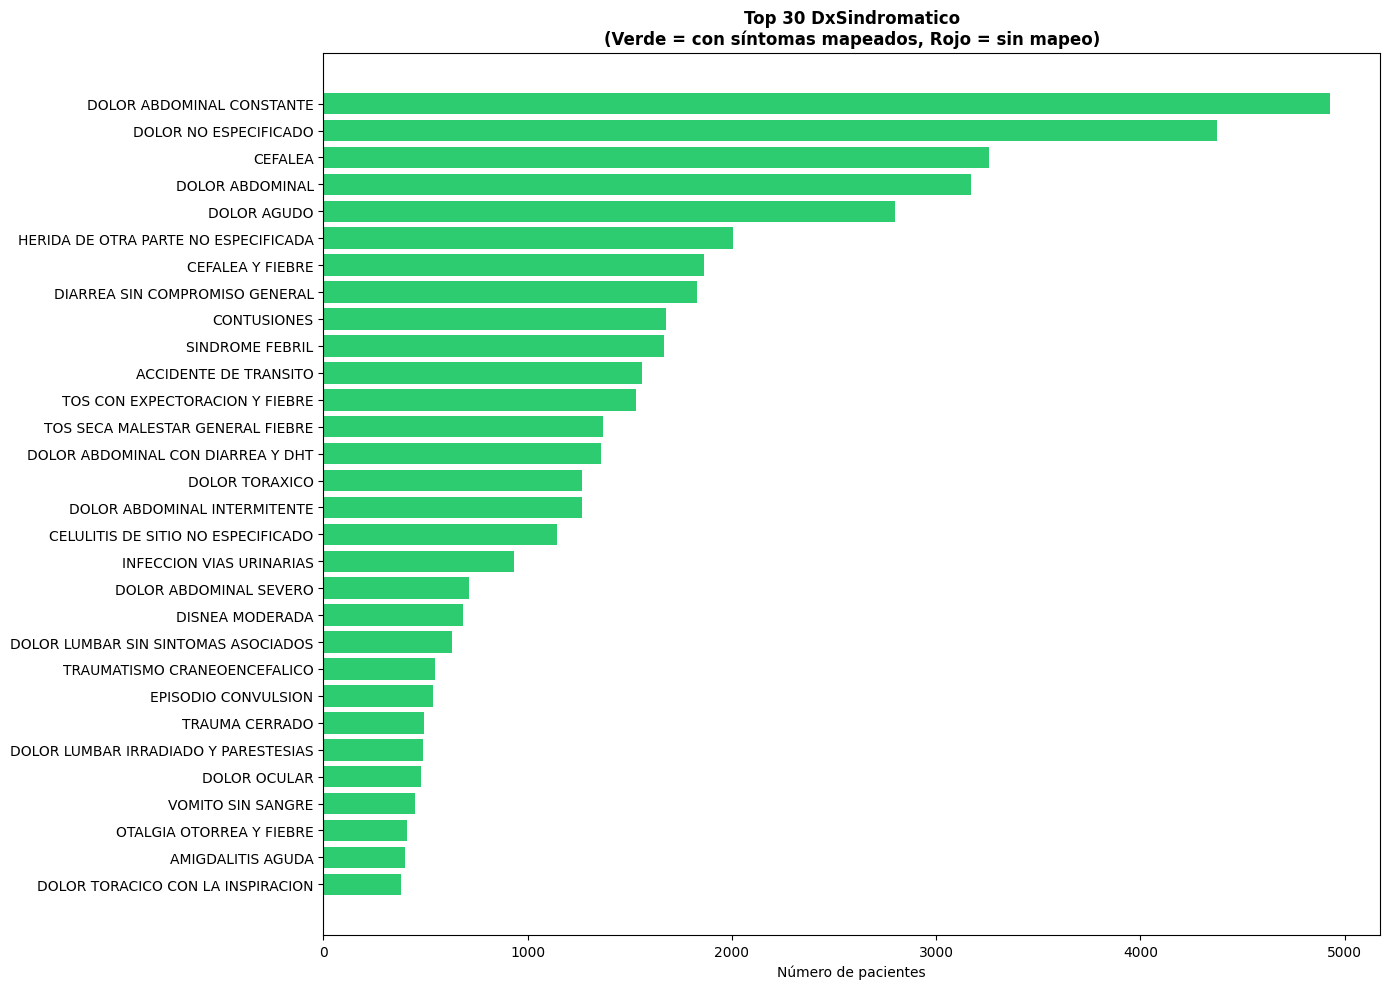

In [5]:
freq_dx = df_h['DxSindromatico'].value_counts().head(30).reset_index()
freq_dx.columns = ['dx', 'n_pacientes']
freq_dx = freq_dx.merge(df_mapeo[['dx_sindromatico', 'n_sintomas']],
                        left_on='dx', right_on='dx_sindromatico', how='left')

fig, ax = plt.subplots(figsize=(14, 10))
colores = ['#2ecc71' if n > 0 else '#e74c3c' for n in freq_dx['n_sintomas']]
bars = ax.barh(freq_dx['dx'][::-1], freq_dx['n_pacientes'][::-1], color=colores[::-1])
ax.set_xlabel('Número de pacientes')
ax.set_title('Top 30 DxSindromatico\n(Verde = con síntomas mapeados, Rojo = sin mapeo)',
             fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Síntomas más usados en el mapeo

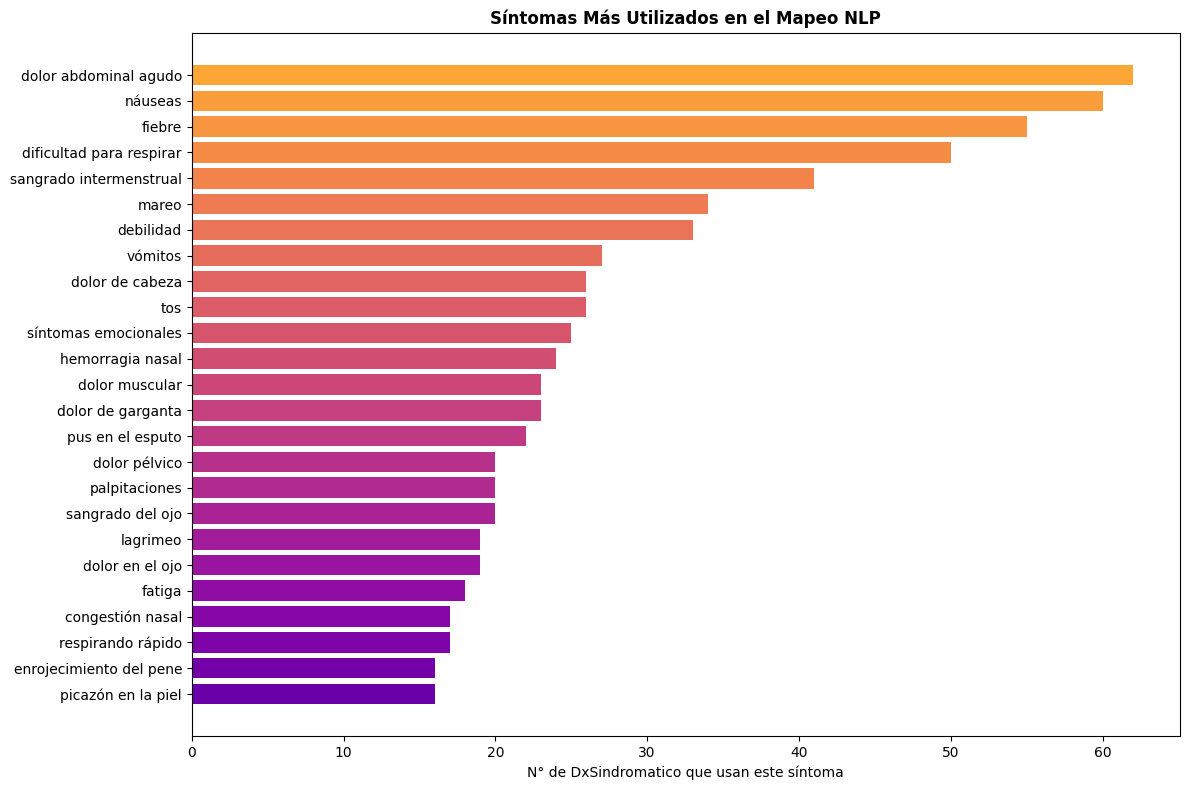

In [6]:
from collections import Counter

todos_los_sintomas = []
for sints in SINDROMATICO_A_SINTOMAS.values():
    todos_los_sintomas.extend(sints)

conteo = Counter(todos_los_sintomas).most_common(25)
nombres = [x[0] for x in conteo]
valores = [x[1] for x in conteo]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(nombres[::-1], valores[::-1],
        color=plt.cm.plasma(np.linspace(0.2, 0.8, len(nombres))))
ax.set_xlabel('N° de DxSindromatico que usan este síntoma')
ax.set_title('Síntomas Más Utilizados en el Mapeo NLP', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Calidad del mapeo: ¿impacto en pacientes?

In [7]:
# ¿Qué % de atenciones del hospital pueden ser procesadas por el pipeline?
dx_con_mapeo = set(SINDROMATICO_A_SINTOMAS.keys())
pacientes_cubiertos = df_h[df_h['DxSindromatico'].isin(dx_con_mapeo)]
total_pacientes = len(df_h)
pct_cubierto = len(pacientes_cubiertos) / total_pacientes * 100

print(f'Total atenciones en el hospital: {total_pacientes:,}')
print(f'Atenciones con DxSindromatico mapeado: {len(pacientes_cubiertos):,} ({pct_cubierto:.1f}%)')
print(f'Atenciones sin cobertura: {total_pacientes - len(pacientes_cubiertos):,}')

# Cobertura por triaje
print('\nCobertura por nivel de triaje:')
for t in sorted(df_h['Triage'].dropna().unique()):
    sub_t = df_h[df_h['Triage'] == t]
    n_cubierto = sub_t['DxSindromatico'].isin(dx_con_mapeo).sum()
    pct = n_cubierto / len(sub_t) * 100
    print(f'  T{int(t)}: {n_cubierto:,}/{len(sub_t):,} = {pct:.1f}%')

Total atenciones en el hospital: 59,025
Atenciones con DxSindromatico mapeado: 58,590 (99.3%)
Atenciones sin cobertura: 435

Cobertura por nivel de triaje:
  T0: 1/1 = 100.0%
  T1: 131/132 = 99.2%
  T2: 4,393/4,472 = 98.2%
  T3: 39,439/39,706 = 99.3%
  T4: 14,603/14,691 = 99.4%
  T5: 23/23 = 100.0%
